In [1]:
from pathlib import Path

DATA_DIR = Path('../data/raw')
print('Data dir exists:', DATA_DIR.exists())
if DATA_DIR.exists():
    for path in sorted(DATA_DIR.iterdir()):
        print(path.name)

Data dir exists: True
ShanghaiTech


In [7]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt


def count_people(gt_dir, label):
    counts = []
    for mat_file in sorted(gt_dir.glob('*.mat')):
        mat = sio.loadmat(mat_file)
        points = mat['image_info'][0, 0][0, 0][0]
        counts.append(len(points))
    counts = np.array(counts)
    print(f"{label}:")
    print(f"  Images: {len(counts)}")
    print(f"  Min: {counts.min()}")
    print(f"  Max: {counts.max()}")
    print(f"  Mean: {counts.mean():.1f}")
    print(f"  Median: {np.median(counts):.1f}")
    print(f"  Std: {counts.std():.1f}")
    return counts


# Part A
counts_A_train = count_people(Path('../data/raw/ShanghaiTech/part_A/train_data/ground-truth'), 'Part A train')
counts_A_test = count_people(Path('../data/raw/ShanghaiTech/part_A/test_data/ground-truth'), 'Part A test')
# Part B
counts_B_train = count_people(Path('../data/raw/ShanghaiTech/part_B/train_data/ground-truth'), 'Part B train')
counts_B_test = count_people(Path('../data/raw/ShanghaiTech/part_B/test_data/ground-truth'), 'Part B test')

Part A train:
  Images: 300
  Min: 33
  Max: 3138
  Mean: 541.4
  Median: 378.0
  Std: 504.3
Part A test:
  Images: 182
  Min: 66
  Max: 2256
  Mean: 433.3
  Median: 307.5
  Std: 353.5
Part B train:
  Images: 400
  Min: 12
  Max: 576
  Mean: 122.9
  Median: 99.0
  Std: 93.8
Part B test:
  Images: 316
  Min: 9
  Max: 539
  Mean: 123.8
  Median: 93.0
  Std: 95.1


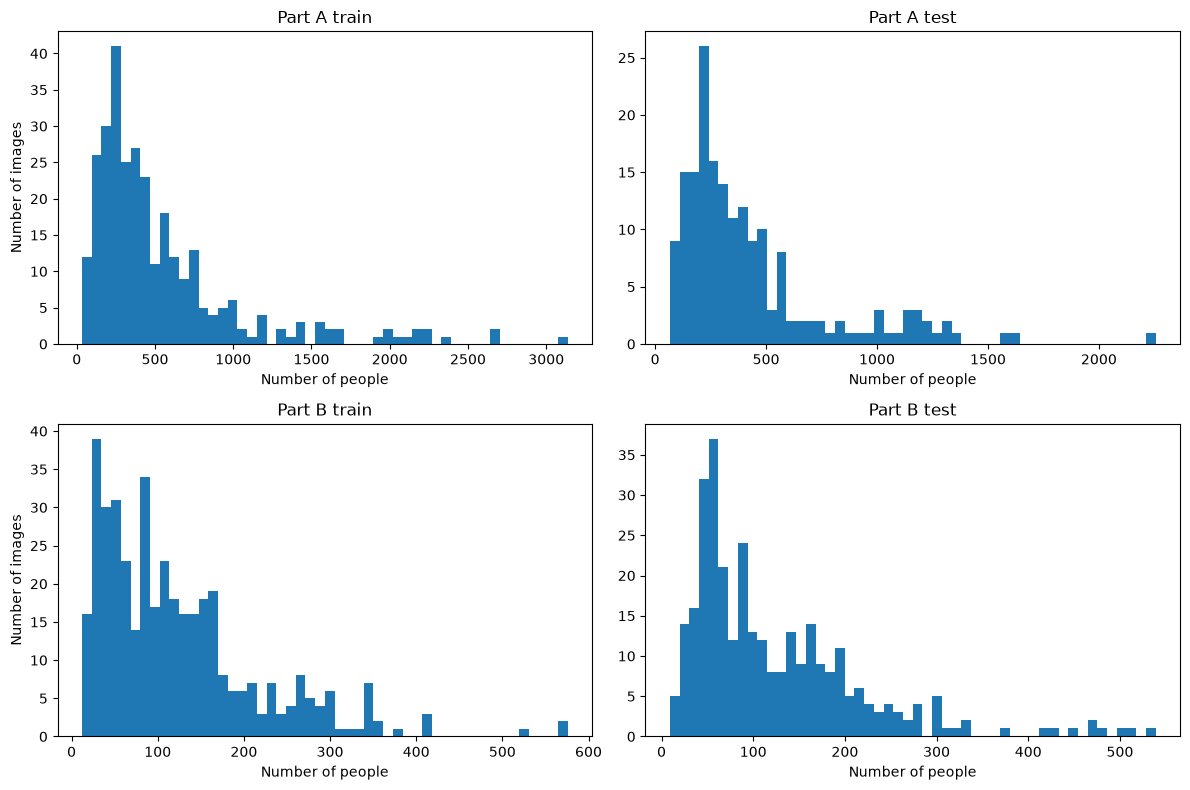

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))              

axes[0, 0].hist(counts_A_train, bins=50)
axes[0, 0].set_title('Part A train')
axes[0, 0].set_xlabel('Number of people')
axes[0, 0].set_ylabel('Number of images')

axes[0, 1].hist(counts_A_test, bins=50)
axes[0, 1].set_title('Part A test')
axes[0, 1].set_xlabel('Number of people')

axes[1, 0].hist(counts_B_train, bins=50)
axes[1, 0].set_title('Part B train')
axes[1, 0].set_xlabel('Number of people')
axes[1, 0].set_ylabel('Number of images')

axes[1, 1].hist(counts_B_test, bins=50)
axes[1, 1].set_title('Part B test')
axes[1, 1].set_xlabel('Number of people')

plt.tight_layout()  

In [9]:
# Image dimensions
from PIL import Image


def get_image_stats(img_dir):
    sizes = []
    for img_file in sorted(img_dir.glob('*.jpg')):
        with Image.open(img_file) as img:
            sizes.append(img.size)
    sizes = np.array(sizes)
    return sizes


folders = [
    ('Part A train', Path('../data/raw/ShanghaiTech/part_A/train_data/images')),
    ('Part A test', Path('../data/raw/ShanghaiTech/part_A/test_data/images')),
    ('Part B train', Path('../data/raw/ShanghaiTech/part_B/train_data/images')),
    ('Part B test', Path('../data/raw/ShanghaiTech/part_B/test_data/images')),
]

for label, img_dir in folders:
    sizes = get_image_stats(img_dir)
    unique_sizes, counts = np.unique(sizes, axis=0, return_counts=True)
    print(f"{label}: {len(sizes)} images")
    print(f"  Unique sizes: {len(unique_sizes)}")
    for size, count in zip(unique_sizes, counts):
        print(f"    {count:3d} images of size {tuple(size)}")
    print()


Part A train: 300 images
  Unique sizes: 189
      1 images of size (np.int64(299), np.int64(450))
      1 images of size (np.int64(329), np.int64(359))
      1 images of size (np.int64(359), np.int64(478))
      1 images of size (np.int64(360), np.int64(270))
      1 images of size (np.int64(370), np.int64(464))
      1 images of size (np.int64(377), np.int64(282))
      1 images of size (np.int64(390), np.int64(498))
      2 images of size (np.int64(400), np.int64(267))
      1 images of size (np.int64(400), np.int64(279))
      1 images of size (np.int64(400), np.int64(300))
      1 images of size (np.int64(400), np.int64(400))
      1 images of size (np.int64(416), np.int64(300))
      1 images of size (np.int64(420), np.int64(182))
      1 images of size (np.int64(432), np.int64(282))
      1 images of size (np.int64(442), np.int64(293))
      1 images of size (np.int64(443), np.int64(411))
      1 images of size (np.int64(444), np.int64(325))
      1 images of size (np.int64(446)

Image size: (1024, 768)
Points range:
  x min/max: 2.324801676395741 1021.8057177069301
  y min/max: 374.9965574015866 753.8667864092203


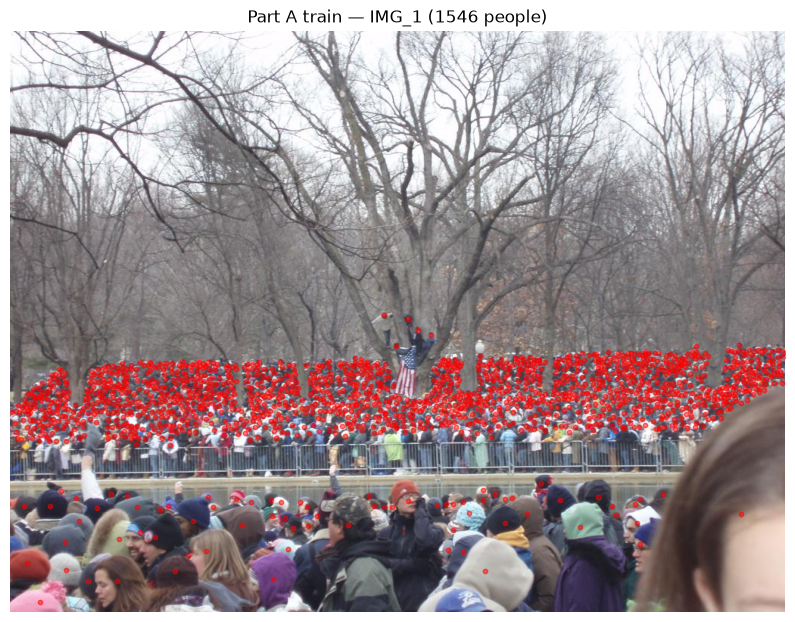

In [10]:
from pathlib import Path

img_path =Path('../data/raw/ShanghaiTech/part_A/train_data/images/IMG_1.jpg')
gt_path =Path('../data/raw/ShanghaiTech/part_A/train_data/ground-truth/GT_IMG_1.mat')  

img =Image.open(img_path)
mat =sio.loadmat(gt_path)
points = mat['image_info'][0, 0][0, 0][0]


plt.figure(figsize=(10, 8))                               
plt.imshow(img)
plt.scatter(points[:, 0], points[:, 1], s=10, c='red',
alpha=0.5)
plt.title('Part A train — IMG_1 (1546 people)')
plt.axis('off')

print("Image size:", img.size)
print("Points range:")
print("  x min/max:", points[:, 0].min(), points[:,
0].max())
print("  y min/max:", points[:, 1].min(), points[:,
1].max())   